# 경구약제 이미지 인식 프로젝트 — tm_final

**YOLOv8m 기반 73클래스 알약 객체 탐지**

| 항목 | 내용 |
|------|------|
| 모델 | YOLOv8m (COCO 사전학습) |
| 클래스 수 | 73개 |
| Train/Val | 1,182장 / 307장 (Multi-label Stratified Split) |
| 이미지 해상도 | 976×1280 (전체 동일, rect=True 적용) |
| 데이터 처리 | 오버샘플링(단순 복사) + 오프라인 증강(회전·이동·스케일 3%) |
| 평가 | Kaggle Private Competition (mAP 기반) |

---

## 파이프라인 요약
```
[원본 JSON] → [전처리] → [Split] → [오버샘플링] → [오프라인 증강]
           → [YOLO 포맷 변환] → [학습] → [Inference] → [submission.csv]
```

---
## 0. 환경 설정 ##

| 구분 | 내용 |
|------|------|
| 학습 환경 | Google Colab (Tesla T4, 14,913MiB VRAM) |
| 로컬 환경 | Mac M4 Pro (MPS, 보조 분석용) |
| Python | 3.12 |
| PyTorch | 2.10.0+cu128 |
| Ultralytics | 8.4.31 |
| 스토리지 | Google Drive (모델·데이터셋 영구 저장) |

In [1]:
# [셀 1] 환경 자동 감지 및 한글 폰트 설정
try:
    import google.colab
    ENV = "colab"
except ImportError:
    ENV = "local"

if ENV == "local":
    BASE_DIR  = "./dataset"
    RUNS_DIR  = "runs/detect"
    FONT_PATH = "C:/Windows/Fonts/malgun.ttf"

elif ENV == "colab":
    from google.colab import drive
    drive.mount('/content/drive')
    import subprocess
    subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)
    BASE_DIR  = "/content/drive/MyDrive/data/초급_프로젝트/dataset"
    RUNS_DIR  = "/content/drive/MyDrive/data/초급_프로젝트/runs/detect"
    FONT_PATH = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont(FONT_PATH)
font_name = fm.FontProperties(fname=FONT_PATH).get_name()
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print(f"환경    : {ENV}")
print(f"폰트    : {font_name}")
print(f"BASE_DIR: {BASE_DIR}")

Mounted at /content/drive
환경    : colab
폰트    : NanumGothic
BASE_DIR: /content/drive/MyDrive/data/초급_프로젝트/dataset


In [ ]:
# [셀 2] 라이브러리 임포트
import os
import json
import cv2
import copy
import shutil
import random
import subprocess
import unicodedata
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from PIL import Image
from collections import Counter, defaultdict
!pip3 install ultralytics -q
from ultralytics import YOLO
from ultralytics.utils import LOGGER
import logging
!pip3 install iterative-stratification -q
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
!pip3 install sahi -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 15.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.4 MB/s eta 0:00:00


In [3]:
# [셀 3] 경로 / 디바이스 / 상수 설정 (tm_final)
import unicodedata

# ── 디바이스 ──────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── 경로 설정 ─────────────────────────────────────────────
TRAIN_JSON_PATH     = os.path.join(BASE_DIR, "merged_annotations_train_final.json")
TEST_JSON_PATH      = os.path.join(BASE_DIR, "merged_annotations_test_final.json")
TRAIN_IMG_DIR       = os.path.join(BASE_DIR, "train_images")
TEST_IMG_DIR        = os.path.join(BASE_DIR, "test_images")
PROCESSED_JSON_PATH = os.path.join(BASE_DIR, "processed_train_tm_final.json")
YOLO_DATASET_DIR    = os.path.join(BASE_DIR, "yolo_dataset_tm_final")
YOLO_RUNS_DIR       = os.path.join(BASE_DIR, "yolo_runs_tm_final")
SUBMISSION_PATH     = os.path.join(BASE_DIR, "submission_tm_final.csv")
YOLO_YAML_PATH      = os.path.join(YOLO_DATASET_DIR, "data.yaml")
AUG_IMG_DIR         = os.path.join(BASE_DIR, "aug_images_tm_final")

for d in [YOLO_DATASET_DIR, YOLO_RUNS_DIR, AUG_IMG_DIR]:
    os.makedirs(d, exist_ok=True)

# ── 경로 검증 ─────────────────────────────────────────────
for name, path in [
    ("TRAIN JSON   ", TRAIN_JSON_PATH),
    ("TEST  JSON   ", TEST_JSON_PATH),
    ("TRAIN IMG DIR", TRAIN_IMG_DIR),
    ("TEST  IMG DIR", TEST_IMG_DIR),
]:
    print(f"  {name} : {'OK' if os.path.exists(path) else '없음'} ({path})")

Device: cuda
  TRAIN JSON    : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_train_final.json)
  TEST  JSON    : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_test_final.json)
  TRAIN IMG DIR : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/train_images)
  TEST  IMG DIR : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/test_images)


---
## 1. 데이터 탐색 (EDA)

원본 데이터의 구조와 품질을 파악한다.  
**주요 확인 항목:** 이미지 수, 해상도 분포, 클래스 불균형, 비정상 BBox

In [4]:
# [셀 4] 이미지 파일 개수 확인
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')

def count_images(directory):
    if not os.path.exists(directory):
        return 0
    return sum(
        1 for entry in os.scandir(directory)
        if entry.is_file() and entry.name.lower().endswith(IMG_EXTENSIONS)
    )

EXPECTED = {"Train": 1489, "Test": 843}

n_train = count_images(TRAIN_IMG_DIR)
n_test  = count_images(TEST_IMG_DIR)

print(f"Train 이미지 수 : {n_train:,}  (기대값: {EXPECTED['Train']:,})")
print(f"Test  이미지 수 : {n_test:,}  (기대값: {EXPECTED['Test']:,})")
print(f"합계            : {n_train + n_test:,}")

if n_train != EXPECTED["Train"]:
    print(f"[경고] Train 이미지 수 불일치: {n_train} != {EXPECTED['Train']}")
if n_test != EXPECTED["Test"]:
    print(f"[경고] Test  이미지 수 불일치: {n_test} != {EXPECTED['Test']}")

Train 이미지 수 : 1,489  (기대값: 1,489)
Test  이미지 수 : 843  (기대값: 843)
합계            : 2,332


In [5]:
# [셀 5] JSON 로드 및 기본 검증
with open(TRAIN_JSON_PATH, 'r', encoding='utf-8') as f:
    train_json = json.load(f)

with open(TEST_JSON_PATH, 'r', encoding='utf-8') as f:
    test_json = json.load(f)

# ── 최상위 키 및 건수 ──────────────────────────────────────
for label, data in [("Train", train_json), ("Test", test_json)]:
    print(f"[{label}] 최상위 키: {list(data.keys())}")
    print(f"  images      : {len(data.get('images', [])):,}건")
    print(f"  annotations : {len(data.get('annotations', [])):,}건")
    print(f"  categories  : {len(data.get('categories', [])):,}건")
    print()

# ── 샘플 1건씩 출력 ───────────────────────────────────────
print("=== images[0] ===")
print(train_json['images'][0])

print("\n=== annotations[0] ===")
print(train_json['annotations'][0])

print("\n=== categories (앞 5개) ===")
for cat in train_json['categories'][:5]:
    print(cat)

# ── category_id 범위 및 연속성 확인 ──────────────────────
cat_ids = sorted(c['id'] for c in train_json['categories'])
expected_ids = list(range(min(cat_ids), max(cat_ids) + 1))
is_continuous = cat_ids == expected_ids

print(f"\ncategory_id 범위 : {min(cat_ids)} ~ {max(cat_ids)}")
print(f"연속성           : {'연속' if is_continuous else '[경고] 불연속 (재매핑 필요)'}")

[Train] 최상위 키: ['images', 'annotations', 'categories']
  images      : 1,489건
  annotations : 4,526건
  categories  : 73건

[Test] 최상위 키: ['images', 'annotations', 'categories']
  images      : 843건
  annotations : 1,129건
  categories  : 73건

=== images[0] ===
{'file_name': 'K-001900-016551-024850-027926_0_2_0_2_90_000_200.png', 'width': 976, 'height': 1280, 'imgfile': 'K-001900-016551-024850-027926_0_2_0_2_90_000_200.png', 'drug_N': 'K-001900', 'drug_S': '정상알약', 'back_color': '연회색 배경', 'drug_dir': '앞면', 'light_color': '주백색', 'camera_la': 90, 'camera_lo': 0, 'size': 200, 'dl_idx': '1899', 'dl_mapping_code': 'K-001900', 'dl_name': '보령부스파정 5mg', 'dl_name_en': 'Buspar Tab. 5mg Boryung', 'img_key': 'http://connectdi.com/design/img/drug/1Mxwka5v0lL.jpg', 'dl_material': '부스피론염산염', 'dl_material_en': 'Buspirone Hydrochloride', 'dl_custom_shape': '정제, 저작정', 'dl_company': '보령제약(주)', 'dl_company_en': 'Boryung', 'di_company_mf': '', 'di_company_mf_en': '', 'item_seq': 198700706, 'di_item_permit_date

클래스 수 : 73  |  전체 어노테이션 : 4,526
평균 : 62.0  |  중앙값 : 35.0  |  최대/최소 비율 : 73.4x

최다 : 기넥신에프정(은행엽엑스)(수출용) (514개)
최소 : 브린텔릭스정 20mg (7개)

상위 5개:
              name  count
기넥신에프정(은행엽엑스)(수출용)    514
       일양하이트린정 2mg    240
        보령부스파정 5mg    180
       뮤테란캡슐 100mg    172
       가바토파정 100mg    143

하위 5개:
        name  count
 졸로푸트정 100mg     11
  쿠에타핀정 25mg     10
자이프렉사정 2.5mg      9
  렉사프로정 15mg      9
 브린텔릭스정 20mg      7


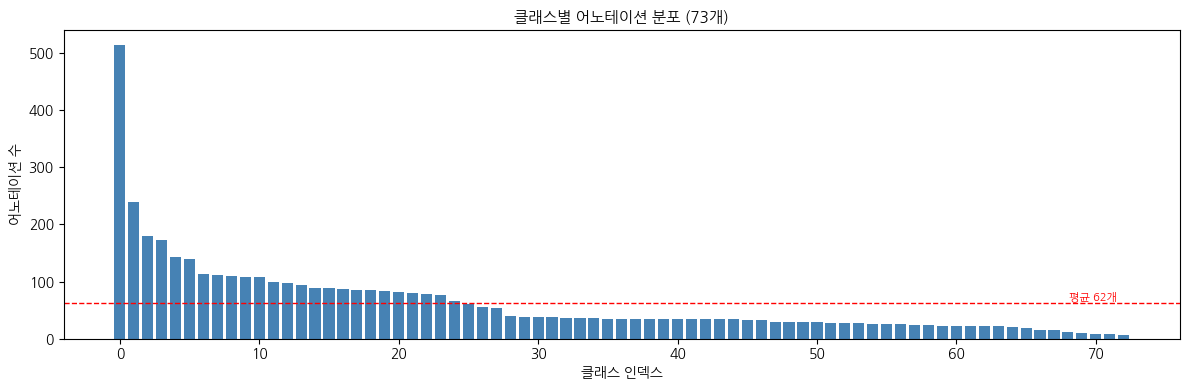

In [6]:
# [셀 6] 클래스 분포 / 알약 수 / 해상도 확인
id2name = {cat['id']: cat['name'] for cat in train_json['categories']}
cat_counter = Counter(annot['category_id'] for annot in train_json['annotations'])

df_class = pd.DataFrame([
    {'category_id': cid, 'name': id2name.get(cid, '?'), 'count': cnt}
    for cid, cnt in cat_counter.most_common()
])

print(f"클래스 수 : {len(df_class)}  |  전체 어노테이션 : {df_class['count'].sum():,}")
print(f"평균 : {df_class['count'].mean():.1f}  |  중앙값 : {df_class['count'].median():.1f}  |  최대/최소 비율 : {df_class['count'].max() / df_class['count'].min():.1f}x")
print(f"\n최다 : {df_class.iloc[0]['name']} ({df_class.iloc[0]['count']}개)")
print(f"최소 : {df_class.iloc[-1]['name']} ({df_class.iloc[-1]['count']}개)")

print("\n상위 5개:")
print(df_class.head(5)[['name', 'count']].to_string(index=False))
print("\n하위 5개:")
print(df_class.tail(5)[['name', 'count']].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(df_class)), df_class['count'], color='steelblue', edgecolor='none')
mean_val = df_class['count'].mean()
ax.axhline(mean_val, color='red', linestyle='--', linewidth=1)
ax.text(len(df_class) * 0.98, mean_val + 5, f"평균 {mean_val:.0f}개", color='red', fontsize=8, ha='right')
ax.set_title('클래스별 어노테이션 분포 (73개)', fontsize=11)
ax.set_xlabel('클래스 인덱스')
ax.set_ylabel('어노테이션 수')
plt.tight_layout()
plt.show()

[Train] 해상도 분포:
  976 x 1280: 1489장
[Test] 해상도 분포:
  976 x 1280: 843장

annotation 없는 이미지: 0장
평균 알약 수: 3.04개 | 최대: 4개

  1개:   64장 (4.3%)
  2개:  302장 (20.3%)
  3개:  634장 (42.6%)
  4개:  489장 (32.8%)


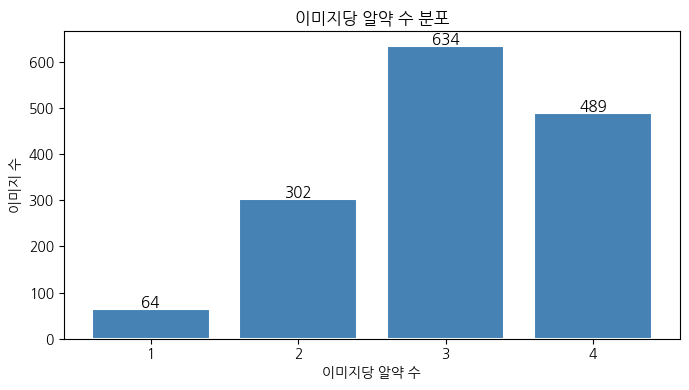

In [7]:
# [셀 6-2] 해상도 및 알약 수 분포 확인
for label, data in [("Train", train_json), ("Test", test_json)]:
    resolutions = Counter((img['width'], img['height']) for img in data['images'])
    print(f"[{label}] 해상도 분포:")
    for (w, h), cnt in resolutions.most_common():
        print(f"  {w} x {h}: {cnt}장")

ann_per_image = Counter(ann['image_id'] for ann in train_json['annotations'])
no_ann = {img['id'] for img in train_json['images']} - set(ann_per_image.keys())
print(f"\nannotation 없는 이미지: {len(no_ann)}장")

counts = list(ann_per_image.values())
pill_dist = Counter(counts)
print(f"평균 알약 수: {np.mean(counts):.2f}개 | 최대: {np.max(counts)}개\n")
for k in sorted(pill_dist.keys()):
    print(f"  {k}개: {pill_dist[k]:4d}장 ({pill_dist[k]/len(train_json['images'])*100:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
keys, vals = zip(*sorted(pill_dist.items()))
bars = ax.bar(keys, vals, color='steelblue', edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 5, str(v), ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('이미지당 알약 수')
ax.set_ylabel('이미지 수')
ax.set_title('이미지당 알약 수 분포')
ax.set_xticks(keys)
plt.tight_layout()
plt.show()

In [8]:
# [셀 7] 비정상 BBox 탐지

# 음수 좌표, 0 이하 크기, 이미지 범위 초과 BBox를 사전 탐지한다.
# 이후 셀에서 해당 annotation을 제거해야 학습 시 오류를 방지할 수 있다.
img_id2info = {img['id']: img for img in train_json['images']}
invalid_bboxes = []

for ann in train_json['annotations']:
    img = img_id2info[ann['image_id']]
    x, y, w, h = ann['bbox']
    iw, ih = img['width'], img['height']

    reasons = []
    if x < 0 or y < 0:           reasons.append(f"음수 좌표 (x={x}, y={y})")
    if w <= 0 or h <= 0:          reasons.append(f"비정상 크기 (w={w}, h={h})")
    if x + w > iw:                reasons.append(f"x 범위 초과 (x+w={x+w} > {iw})")
    if y + h > ih:                reasons.append(f"y 범위 초과 (y+h={y+h} > {ih})")
    if reasons:
        invalid_bboxes.append({
            'ann_id'  : ann['id'],
            'image_id': ann['image_id'],
            'bbox'    : ann['bbox'],
            'reason'  : ' / '.join(reasons)
        })

print(f"비정상 BBox 수: {len(invalid_bboxes)}개")
for item in invalid_bboxes:
    print(f"  ann_id={item['ann_id']} / image_id={item['image_id']} / bbox={item['bbox']} / 사유={item['reason']}")

비정상 BBox 수: 2개
  ann_id=903 / image_id=239 / bbox=[6567, 625, 311, 315] / 사유=x 범위 초과 (x+w=6878 > 976)
  ann_id=1157 / image_id=310 / bbox=[653, 8889, 217, 217] / 사유=y 범위 초과 (y+h=9106 > 1280)


In [9]:
# [셀 8] 파일 매칭 검증
actual_files = {entry.name for entry in os.scandir(TRAIN_IMG_DIR) if entry.is_file()}

missing = []
for img in train_json['images']:
    if img['file_name'] not in actual_files:
        missing.append(img['file_name'])

print(f"JSON 등록 이미지 수  : {len(train_json['images']):,}장")
print(f"실제 파일 수         : {len(actual_files):,}장")
print(f"매칭 실패 (누락 파일): {len(missing)}장")

if missing:
    print("\n누락 파일 목록:")
    for f in missing:
        print(f"  {f}")
else:
    print("모든 파일 정상 매칭")

JSON 등록 이미지 수  : 1,489장
실제 파일 수         : 1,489장
매칭 실패 (누락 파일): 0장
모든 파일 정상 매칭


---
## 2. 데이터 전처리

### 전처리 순서
```
1. 비정상 BBox 제거  →  ann_id 903, 1157 (음수 좌표 / 범위 초과)
2. category_id 재매핑  →  원본 비연속 ID → 0~72 연속 정수
3. Multi-label Stratified Split  →  Train 1,182장 / Val 307장
```

> **핵심:** 일반 random split은 일부 클래스가 Val에만 배정되는 문제가 생긴다.  
> `iterative-stratification` 라이브러리로 73개 클래스 전부 Train/Val 양쪽에 포함되도록 보장한다.

In [ ]:
# [셀 9] 비정상 BBox 제거
invalid_ann_ids = {item['ann_id'] for item in invalid_bboxes}
clean_annotations = [ann for ann in train_json['annotations'] if ann['id'] not in invalid_ann_ids]

print(f"제거 전 : {len(train_json['annotations']):,}개")
print(f"제거 수 : {len(invalid_ann_ids)}개")
print(f"제거 후 : {len(clean_annotations):,}개")

제거 전 : 4,526개
제거 수 : 2개
제거 후 : 4,524개


In [11]:
# [셀 10] category_id 재매핑 (원본 id → 0~72 연속 정수)

# YOLO는 클래스 id가 0부터 시작하는 연속 정수여야 한다.
# 원본 id(1899~44198)를 0~72로 재매핑하고,
# 제출 시에는 반대 방향(new_id2old) + 1 보정으로 원복한다.

sorted_cats = sorted(train_json['categories'], key=lambda c: c['id'])

old_id2new  = {cat['id']: new_id for new_id, cat in enumerate(sorted_cats)}
new_id2old  = {new_id: cat['id'] for new_id, cat in enumerate(sorted_cats)}
new_id2name = {new_id: cat['name'].strip() for new_id, cat in enumerate(sorted_cats)}

remapped_annotations = []
for ann in clean_annotations:
    new_ann = ann.copy()
    new_ann['category_id'] = old_id2new[ann['category_id']]
    remapped_annotations.append(new_ann)

remapped_categories = [
    {'id': new_id, 'name': new_id2name[new_id], 'supercategory': 'pill'}
    for new_id in range(len(sorted_cats))
]

new_cat_ids = sorted(set(ann['category_id'] for ann in remapped_annotations))
print(f"category_id 범위 : {min(new_cat_ids)} ~ {max(new_cat_ids)}")
print(f"고유 클래스 수   : {len(new_cat_ids)}개")
print(f"연속성           : {'연속' if new_cat_ids == list(range(len(new_cat_ids))) else '[경고] 불연속'}")
print(f"annotation 수    : {len(remapped_annotations):,}개")

category_id 범위 : 0 ~ 72
고유 클래스 수   : 73개
연속성           : 연속
annotation 수    : 4,524개


In [13]:
# [셀 11] Train/Val Multi-label Stratified Split

# 일반 random split은 일부 클래스가 Val에만 배정될 위험이 있다.
# iterative-stratification 라이브러리로 73개 클래스 모두
# Train/Val 양쪽에 포함되도록 보장한다.
# 클래스당 이미지가 1장인 경우는 강제로 Train에 배정한다.

processed_annotations = remapped_annotations

img2anns = {}
for ann in processed_annotations:
    img2anns.setdefault(ann['image_id'], []).append(ann)

img_ids   = np.array(sorted(img2anns.keys()))
n_classes = len(remapped_categories)

y = np.zeros((len(img_ids), n_classes), dtype=int)
for i, img_id in enumerate(img_ids):
    for ann in img2anns[img_id]:
        y[i, ann['category_id']] = 1

class_counts     = y.sum(axis=0)
single_classes   = np.where(class_counts == 1)[0]
force_train_mask = np.any(y[:, single_classes] == 1, axis=1) if len(single_classes) > 0 else np.zeros(len(img_ids), dtype=bool)

remaining_idx = np.where(~force_train_mask)[0]
force_idx     = np.where(force_train_mask)[0]

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(msss.split(remaining_idx, y[remaining_idx]))

train_ids = img_ids[remaining_idx[train_idx]].tolist() + img_ids[force_idx].tolist()
val_ids   = img_ids[remaining_idx[val_idx]].tolist()

train_y = y[[i for i, img_id in enumerate(img_ids) if img_id in set(train_ids)]]
val_y   = y[[i for i, img_id in enumerate(img_ids) if img_id in set(val_ids)]]

print(f"Train : {len(train_ids)}장 | Val : {len(val_ids)}장")
print(f"Train 클래스 수 : {train_y.sum(axis=0).astype(bool).sum()}개")
print(f"Val   클래스 수 : {val_y.sum(axis=0).astype(bool).sum()}개")
print(f"강제 train 배정 : {len(force_idx)}장")

Train : 1182장 | Val : 307장
Train 클래스 수 : 73개
Val   클래스 수 : 73개
강제 train 배정 : 0장


---
## 3. 데이터 증강 파이프라인

### 3-1. 오버샘플링 설계

| 항목 | 내용 |
|------|------|
| 대상 | Train 기준 annotation 62개(전체 평균) 미만 클래스 — 51개 |
| 방식 | 단순 이미지 복사 (증강 없음) |
| 목표 | 클래스당 62개 |
| 결과 | Train 1,182장 → 2,547장 (+1,365장) |

**트러블슈팅 요약**

| 단계 | 문제 | 해결 |
|------|------|------|
| 1차 | 단순 while 루프 → class 8: 23→183 (TARGET 초과) | add_count 사전 계산 후 조건부 복사 |
| 2차 | running_count 공유 → spillover 발생 | 허용 수준으로 판단, 진행 |

In [14]:
# [셀 11-1] 오버샘플링 (Train only, annotation < 62 클래스 대상)

# annotation 62개(전체 평균) 미만인 51개 클래스를 대상으로
# 해당 클래스가 포함된 이미지를 단순 복사한다.
#
# 핵심 로직:
#   - add_count 사전 계산: 이미지 복사 전에 해당 이미지의
#     대상 클래스 annotation 수를 미리 계산하여 TARGET 초과를 방지
#   - stall_count: 더 이상 복사 가능한 이미지가 없으면 루프 종료
#
# 주의: running_count 공유 카운터 구조상 일부 클래스에서
#       spillover(소량 초과)가 발생할 수 있으나 허용 범위로 판단함


TARGET_COUNT = 62

train_img_id_set = set(train_ids)
train_anns = [ann for ann in remapped_annotations if ann["image_id"] in train_img_id_set]
running_count = Counter(ann["category_id"] for ann in train_anns)

target_classes = {cid for cid, cnt in running_count.items() if cnt < TARGET_COUNT}
print(f"오버샘플링 대상 클래스 수: {len(target_classes)}개")

cls_to_img_ids = defaultdict(list)
for ann in train_anns:
    if ann["category_id"] in target_classes:
        cls_to_img_ids[ann["category_id"]].append(ann["image_id"])
for cid in cls_to_img_ids:
    cls_to_img_ids[cid] = list(set(cls_to_img_ids[cid]))

img_id_to_info = {img["id"]: img for img in train_json["images"]}
img_id_to_anns = defaultdict(list)
for ann in remapped_annotations:
    img_id_to_anns[ann["image_id"]].append(ann)

img_cid_count = defaultdict(lambda: defaultdict(int))
for ann in train_anns:
    img_cid_count[ann["image_id"]][ann["category_id"]] += 1

new_images = []
new_anns   = []
new_img_id = max(img["id"] for img in train_json["images"]) + 1
new_ann_id = max(ann["id"] for ann in remapped_annotations) + 1

for cid in target_classes:
    src_img_ids = cls_to_img_ids[cid]
    idx         = 0
    stall_count = 0

    while running_count[cid] < TARGET_COUNT:
        src_id    = src_img_ids[idx % len(src_img_ids)]
        add_count = img_cid_count[src_id][cid]

        if running_count[cid] + add_count <= TARGET_COUNT:
            new_img       = copy.deepcopy(img_id_to_info[src_id])
            new_img["id"] = new_img_id
            new_images.append(new_img)
            for ann in img_id_to_anns[src_id]:
                new_ann             = copy.deepcopy(ann)
                new_ann["id"]       = new_ann_id
                new_ann["image_id"] = new_img_id
                new_anns.append(new_ann)
                new_ann_id += 1
                running_count[ann["category_id"]] += 1
            new_img_id  += 1
            stall_count  = 0
        else:
            stall_count += 1

        if stall_count >= len(src_img_ids):
            break

        idx += 1

new_img_id_set          = {img["id"] for img in new_images}
original_count          = Counter(ann["category_id"] for ann in train_anns)

print(f"추가된 이미지 수: {len(new_images)}장")
print(f"추가된 annotation 수: {len(new_anns)}개")
print(f"\n=== 오버샘플링 전후 비교 (대상 클래스) ===")
print(f"{'class_id':>10} {'class_name':<40} {'before':>8} {'after':>8}")
for cid in sorted(target_classes):
    print(f"{cid:>10} {new_id2name.get(cid, 'unknown'):<40} {original_count[cid]:>8} {running_count[cid]:>8}")

오버샘플링 대상 클래스 수: 51개
추가된 이미지 수: 1365장
추가된 annotation 수: 4247개

=== 오버샘플링 전후 비교 (대상 클래스) ===
  class_id class_name                                 before    after
         5 알드린정                                           43      106
         6 뉴로메드정(옥시라세탐)                                   22       73
         7 타이레놀정500mg                                     26       72
         8 에어탈정(아세클로페낙)                                   23      165
         9 삼남건조수산화알루미늄겔정                                  44       94
        10 타이레놀이알서방정(아세트아미노펜)(수출용)                        28       70
        11 삐콤씨에프정 618.6mg/병                               27       72
        12 조인스정 200mg                                     28      162
        13 쎄로켈정 100mg                                     28       65
        14 리렉스펜정 300mg/PTP                                28       69
        15 아빌리파이정 10mg                                    13       65
        16 자이프렉사정 2.5mg                                    7       62

### 3-2. 오프라인 증강 설계

오버샘플링으로 추가된 이미지에만 오프라인 affine 변환을 적용한다.  
원본 이미지는 그대로 유지하여 학습 안정성을 확보한다.

| 파라미터 | 값 | 선택 근거 |
|---------|----|-----------|
| 회전 | ±3도 | 촬영 시 발생 가능한 미세 각도 변화 |
| 이동 | ±3% | 약의 위치 미세 변화 |
| 스케일 | ±3% | 카메라 거리 차이로 인한 크기 변화 |
| HSV | 제거 | 균일한 조명 환경에서 색상 증강은 역효과 (v6 실험 확인) |
| mosaic | 0.0 | 원본/증강 이미지 혼합 시 스타일 충돌 방지 (v6 교훈) |

> **v5~v7 증강 실험 결론:**  
> 이 데이터셋은 촬영 환경이 균일(동일 해상도·배경·조명)하여 증강이 오히려 노이즈로 작용한다.  
> 오프라인 경량 증강(3%)이 학습 안정성을 개선하는 최적 타협점이다.

In [15]:
# [셀 11-2] 오버샘플링 이미지에만 오프라인 증강 적용 (회전3%, 이동3%, 스케일3%)

# 오버샘플링으로 추가된 이미지(단순 복사)에만 affine 변환을 적용한다.
# 원본 이미지는 증강하지 않아 학습 안정성을 유지한다.
#
# 증강 파라미터 선택 근거:
#   - 회전 ±3도: 실제 약 촬영 시 발생 가능한 미세 각도 변화 반영
#   - 이동 ±3%: 약의 위치가 약간 이동한 상황 반영
#   - 스케일 ±3%: 카메라 거리 차이로 인한 크기 변화 반영
#   - HSV 제거: 조명이 균일한 환경에서 색상 증강은 역효과 (v6에서 확인)
#   - mosaic=0.0: 원본/증강 이미지 혼합 시 스타일 불일치 방지 (v6 교훈)
#
# BBox 변환: 4개 코너 좌표에 동일한 affine 행렬을 적용한 후
#            AABB(축 정렬 경계 박스)로 재계산


random.seed(42)
np.random.seed(42)

DEGREES   = 3.0
TRANSLATE = 0.03
SCALE     = 0.03

def augment_affine(img, anns, degrees, translate, scale, img_w, img_h):
    angle = random.uniform(-degrees, degrees)
    tx    = random.uniform(-translate, translate) * img_w
    ty    = random.uniform(-translate, translate) * img_h
    sc    = 1.0 + random.uniform(-scale, scale)

    cx, cy = img_w / 2, img_h / 2
    M = cv2.getRotationMatrix2D((cx, cy), angle, sc)
    M[0, 2] += tx
    M[1, 2] += ty

    img_aug = cv2.warpAffine(img, M, (img_w, img_h),
                              borderMode=cv2.BORDER_REFLECT_101)
    new_anns = []
    for ann in anns:
        x, y, w, h = ann["bbox"]
        corners = np.array([
            [x,     y    ],
            [x + w, y    ],
            [x + w, y + h],
            [x,     y + h],
        ], dtype=np.float32)
        ones      = np.ones((4, 1), dtype=np.float32)
        corners_h = np.hstack([corners, ones])
        corners_t = (M @ corners_h.T).T

        x_min = np.clip(corners_t[:, 0].min(), 0, img_w)
        y_min = np.clip(corners_t[:, 1].min(), 0, img_h)
        x_max = np.clip(corners_t[:, 0].max(), 0, img_w)
        y_max = np.clip(corners_t[:, 1].max(), 0, img_h)

        new_w = x_max - x_min
        new_h = y_max - y_min

        if new_w <= 1 or new_h <= 1:
            continue

        new_ann         = copy.deepcopy(ann)
        new_ann["bbox"] = [float(x_min), float(y_min), float(new_w), float(new_h)]
        new_anns.append(new_ann)

    return img_aug, new_anns

new_img_id_to_anns = defaultdict(list)
for ann in new_anns:
    new_img_id_to_anns[ann["image_id"]].append(ann)

aug_img_fname_map = {}
aug_ann_map       = {}
fail_count        = 0

print(f"오프라인 증강 시작: {len(new_images)}장")

for new_img in new_images:
    img_id     = new_img["id"]
    orig_fname = new_img["file_name"]
    src_path   = os.path.join(TRAIN_IMG_DIR, orig_fname)

    img = cv2.imread(src_path)
    if img is None:
        fail_count += 1
        continue

    img_h, img_w = img.shape[:2]
    img_aug, aug_anns = augment_affine(
        img, new_img_id_to_anns[img_id],
        DEGREES, TRANSLATE, SCALE, img_w, img_h
    )

    aug_fname = f"aug_{img_id}_{orig_fname}"
    save_path = os.path.join(AUG_IMG_DIR, aug_fname)
    cv2.imwrite(save_path, img_aug)

    aug_img_fname_map[img_id] = aug_fname
    aug_ann_map[img_id]       = aug_anns

print(f"증강 완료: {len(aug_img_fname_map)}장 | 실패: {fail_count}장")
print(f"저장 경로: {AUG_IMG_DIR}")

오프라인 증강 시작: 1365장
증강 완료: 1365장 | 실패: 0장
저장 경로: /content/drive/MyDrive/data/초급_프로젝트/dataset/aug_images_tm_final


In [16]:
# [셀 12] 전처리 JSON 저장 (tm_final)

# 오버샘플링 이미지의 file_name을 증강된 파일명으로 교체하고,
# annotation 좌표도 증강 후 좌표로 대체한다.
# 이후 세션이 초기화되어도 이 JSON 파일로 모든 정보를 복원 가능하다.


new_images_aug = []
for img in new_images:
    img_copy = copy.deepcopy(img)
    if img_copy["id"] in aug_img_fname_map:
        img_copy["file_name"] = aug_img_fname_map[img_copy["id"]]
    new_images_aug.append(img_copy)

aug_new_anns = []
for ann in new_anns:
    if ann["image_id"] in aug_ann_map:
        continue
    aug_new_anns.append(copy.deepcopy(ann))

for img_id, anns in aug_ann_map.items():
    for ann in anns:
        aug_new_anns.append(copy.deepcopy(ann))

oversampled_annotations_tm_final = remapped_annotations + aug_new_anns

processed_json = {
    'images'     : train_json['images'] + new_images_aug,
    'annotations': oversampled_annotations_tm_final,
    'categories' : remapped_categories,
    'train_ids'  : list(train_ids),
    'val_ids'    : list(val_ids),
    'mappings'   : {
        'old_id2new' : {str(k): v for k, v in old_id2new.items()},
        'new_id2old' : {str(k): v for k, v in new_id2old.items()},
        'new_id2name': {str(k): v for k, v in new_id2name.items()},
    }
}

with open(PROCESSED_JSON_PATH, 'w', encoding='utf-8') as f:
    json.dump(processed_json, f, ensure_ascii=False, indent=2)

with open(PROCESSED_JSON_PATH, 'r', encoding='utf-8') as f:
    verify = json.load(f)

print(f"images      : {len(verify['images']):,}장")
print(f"annotations : {len(verify['annotations']):,}개")
print(f"categories  : {len(verify['categories'])}개")
print(f"train_ids   : {len(verify['train_ids']):,}장")
print(f"val_ids     : {len(verify['val_ids']):,}장")
cat_ids = [ann['category_id'] for ann in verify['annotations']]
print(f"category_id : {min(cat_ids)} ~ {max(cat_ids)}")
orig_ann_cnt = len(remapped_annotations)
aug_ann_cnt  = len(aug_new_anns)
print(f"\n원본 annotation 수  : {orig_ann_cnt:,}개")
print(f"증강 annotation 수  : {aug_ann_cnt:,}개")
print(f"총 annotation 수    : {orig_ann_cnt + aug_ann_cnt:,}개")

images      : 2,854장
annotations : 8,771개
categories  : 73개
train_ids   : 1,182장
val_ids     : 307장
category_id : 0 ~ 72

원본 annotation 수  : 4,524개
증강 annotation 수  : 4,247개
총 annotation 수    : 8,771개


In [17]:
# [셀 13] 전처리 최종 검증 (tm_final)

# 학습 전 마지막 품질 검사:
#   1. 비정상 BBox 재확인 (증강 후 좌표가 범위 내에 있는지)
#   2. Train/Val 클래스 분포 비율 검증 (Val 비율 20% ± 15% 허용)


train_id_set      = set(train_ids)
val_id_set        = set(val_ids)
all_images        = train_json['images'] + new_images_aug

train_annotations = [ann for ann in oversampled_annotations_tm_final
                     if ann['image_id'] in train_id_set or ann['image_id'] in new_img_id_set]
val_annotations   = [ann for ann in oversampled_annotations_tm_final
                     if ann['image_id'] in val_id_set]

img_id2info = {img['id']: img for img in all_images}
bbox_errors = []
for ann in oversampled_annotations_tm_final:
    img_info = img_id2info.get(ann['image_id'])
    if img_info is None:
        continue
    x, y, w, h = ann['bbox']
    iw = img_info['width']
    ih = img_info['height']
    reasons = []
    if x < 0 or y < 0:  reasons.append(f"음수 좌표 (x={x:.1f}, y={y:.1f})")
    if w <= 0 or h <= 0: reasons.append(f"비정상 크기 (w={w:.1f}, h={h:.1f})")
    if x + w > iw:       reasons.append(f"x 범위 초과 ({x+w:.1f} > {iw})")
    if y + h > ih:       reasons.append(f"y 범위 초과 ({y+h:.1f} > {ih})")
    if reasons:
        bbox_errors.append({'ann_id': ann['id'], 'reason': ' / '.join(reasons)})

print(f"비정상 BBox : {len(bbox_errors)}개" + (f"\n  {bbox_errors}" if bbox_errors else " (정상)"))

total_cat_counts = Counter(ann['category_id'] for ann in remapped_annotations)
train_cat_counts = Counter(ann['category_id'] for ann in train_annotations)
val_cat_counts   = Counter(ann['category_id'] for ann in val_annotations)

print(f"\n{'new_id':<8} {'클래스명':<40} {'전체':>6} {'Train':>6} {'Val':>5} {'Val비율':>8}")
print("-" * 70)
ratio_errors = []
for cat_id in range(len(remapped_categories)):
    total     = total_cat_counts.get(cat_id, 0)
    train     = train_cat_counts.get(cat_id, 0)
    val       = val_cat_counts.get(cat_id, 0)
    val_ratio = val / total if total > 0 else 0
    flag      = " [경고]" if abs(val_ratio - 0.2) > 0.15 and total >= 5 else ""
    print(f"  {cat_id:<6} {new_id2name[cat_id]:<40} {total:>6} {train:>6} {val:>5} {val_ratio:>7.1%}{flag}")
    if flag:
        ratio_errors.append(cat_id)

print(f"\n비율 이상 클래스 : {len(ratio_errors)}개")
print(f"Train 클래스 수  : {len(train_cat_counts)}개")
print(f"Val   클래스 수  : {len(val_cat_counts)}개")
print(f"\nTrain annotation 수 (오버샘플링 포함) : {len(train_annotations):,}개")
print(f"Val   annotation 수                  : {len(val_annotations):,}개")

비정상 BBox : 0개 (정상)

new_id   클래스명                                         전체  Train   Val    Val비율
----------------------------------------------------------------------
  0      보령부스파정 5mg                                  180    353    36   20.0%
  1      뮤테란캡슐 100mg                                 172    319    32   18.6%
  2      일양하이트린정 2mg                                 240    585    48   20.0%
  3      기넥신에프정(은행엽엑스)(수출용)                          514    421   103   20.0%
  4      무코스타정(레바미피드)(비매품)                            98    374    20   20.4%
  5      알드린정                                         54    106    11   20.4%
  6      뉴로메드정(옥시라세탐)                                 27     73     5   18.5%
  7      타이레놀정500mg                                   33     72     7   21.2%
  8      에어탈정(아세클로페낙)                                 29    165     6   20.7%
  9      삼남건조수산화알루미늄겔정                                56     94    12   21.4%
  10     타이레놀이알서방정(아세트아미노펜)(수출용)                  

## 4. YOLO 포맷 변환 ##

| 구분 | 이미지 수 | 라벨 수 |
|------|---------|--------|
| Train | 2,547장 | 2,547개 |
| Val | 307장 | 307개 |

> ✅ 이미지 복사 성공 시에만 라벨 파일을 작성하여 이미지/라벨 수 불일치를 방지한다.

In [18]:
# [셀 14] YOLO 포맷 변환 (tm_final)

# COCO 포맷(x, y, w, h 절대 좌표)을 YOLO 포맷(cx, cy, w, h 정규화)으로 변환한다.
#
# 핵심 처리:
#   - 이미지 복사 성공 시에만 라벨 파일 작성 → 이미지/라벨 수 불일치 방지
#   - 오버샘플링 이미지: 증강된 파일(AUG_IMG_DIR) 우선, 없으면 원본 fallback
#   - data.yaml: 절대 경로로 작성하여 Colab/로컬 환경 모두 호환


YOLO_LABEL_TRAIN = os.path.join(YOLO_DATASET_DIR, "labels", "train")
YOLO_LABEL_VAL   = os.path.join(YOLO_DATASET_DIR, "labels", "val")
YOLO_IMG_TRAIN   = os.path.join(YOLO_DATASET_DIR, "images", "train")
YOLO_IMG_VAL     = os.path.join(YOLO_DATASET_DIR, "images", "val")

for d in [YOLO_LABEL_TRAIN, YOLO_LABEL_VAL, YOLO_IMG_TRAIN, YOLO_IMG_VAL]:
    os.makedirs(d, exist_ok=True)

def coco_to_yolo(bbox, img_w, img_h):
    x, y, w, h = bbox
    x_c = min(max((x + w / 2) / img_w, 0.0), 1.0)
    y_c = min(max((y + h / 2) / img_h, 0.0), 1.0)
    w_n = min(max(w / img_w, 0.0), 1.0)
    h_n = min(max(h / img_h, 0.0), 1.0)
    return x_c, y_c, w_n, h_n

# 전체 이미지 정보 (원본 + 오버샘플링)
all_images_list = train_json["images"] + new_images_aug
img_id2info     = {img["id"]: img for img in all_images_list}

# image_id → annotation 목록 (오버샘플링 + 증강 좌표 반영)
img_id2anns = {}
for ann in oversampled_annotations_tm_final:
    img_id2anns.setdefault(ann["image_id"], []).append(ann)

def write_yolo(img_ids, label_dir, img_dir, is_train=False):
    img_id_set = set(img_ids)
    if is_train:
        img_id_set = img_id_set | new_img_id_set
    skip_count = 0
    for img_id in img_id_set:
        img_info = img_id2info.get(img_id)
        if img_info is None:
            continue
        fname = img_info["file_name"]
        stem  = os.path.splitext(fname)[0]

        # 이미지 경로 결정
        if img_id in new_img_id_set:
            aug_path  = os.path.join(AUG_IMG_DIR, fname)
            prefix    = f"aug_{img_id}_"
            orig_name = fname[len(prefix):] if fname.startswith(prefix) else fname
            orig_path = os.path.join(TRAIN_IMG_DIR, orig_name)
            src_path  = aug_path if os.path.exists(aug_path) else orig_path
        else:
            src_path = os.path.join(TRAIN_IMG_DIR, fname)

        if not os.path.exists(src_path):
            skip_count += 1
            continue

        # 이미지 복사 성공 시에만 라벨 작성
        dst_path = os.path.join(img_dir, fname)
        shutil.copy2(src_path, dst_path)

        label_path = os.path.join(label_dir, stem + ".txt")
        with open(label_path, "w") as f:
            for ann in img_id2anns.get(img_id, []):
                x_c, y_c, w_n, h_n = coco_to_yolo(
                    ann["bbox"], img_info["width"], img_info["height"]
                )
                f.write(f"{ann['category_id']} {x_c:.6f} {y_c:.6f} {w_n:.6f} {h_n:.6f}\n")

    return skip_count

skip_train = write_yolo(train_ids, YOLO_LABEL_TRAIN, YOLO_IMG_TRAIN, is_train=True)
skip_val   = write_yolo(val_ids,   YOLO_LABEL_VAL,   YOLO_IMG_VAL,   is_train=False)

# data.yaml 생성
yaml_content = f"""train: {YOLO_IMG_TRAIN}
val: {YOLO_IMG_VAL}

nc: {len(remapped_categories)}
names: {[new_id2name[i] for i in range(len(remapped_categories))]}
"""
with open(YOLO_YAML_PATH, "w", encoding="utf-8") as f:
    f.write(yaml_content)

n_ti = len(os.listdir(YOLO_IMG_TRAIN))
n_vi = len(os.listdir(YOLO_IMG_VAL))
n_tl = len(os.listdir(YOLO_LABEL_TRAIN))
n_vl = len(os.listdir(YOLO_LABEL_VAL))

print(f"Train 이미지: {n_ti:,} / 라벨: {n_tl:,}")
print(f"Val   이미지: {n_vi:,} / 라벨: {n_vl:,}")
print(f"복사 실패 (train): {skip_train}장 | 복사 실패 (val): {skip_val}장")
if n_ti != n_tl: print("[경고] Train 이미지/라벨 수 불일치")
if n_vi != n_vl: print("[경고] Val 이미지/라벨 수 불일치")

if os.listdir(YOLO_LABEL_TRAIN):
    sample = os.listdir(YOLO_LABEL_TRAIN)[0]
    print(f"\n샘플 라벨 ({sample}):")
    with open(os.path.join(YOLO_LABEL_TRAIN, sample)) as f:
        print(f.read())

Train 이미지: 2,547 / 라벨: 2,547
Val   이미지: 307 / 라벨: 307
복사 실패 (train): 0장 | 복사 실패 (val): 0장

샘플 라벨 (K-001900-016551-024850-027926_0_2_0_2_90_000_200.txt):
0 0.265369 0.245703 0.206967 0.099219
23 0.773566 0.215234 0.413934 0.313281



---
## 5. 모델 학습

### 하이퍼파라미터 설정 근거

| 파라미터 | 값 | 근거 |
|---------|----|----- |
| imgsz | 1280 | 원본 해상도(976×1280) 유지 → 작은 알약 탐지 품질 향상 |
| rect | True | 패딩 없이 원본 비율 유지 → 속도·정확도 개선 |
| batch | 8 | 오버샘플링으로 이미지 수 증가 → OOM 방지 |
| optimizer | AdamW | 딥러닝 범용 고성능 옵티마이저 |
| mosaic | 0.0 | 오프라인 증강 이미지와의 충돌 방지 |
| patience | 20 | 충분한 수렴 기회 부여 |
| amp | True | 자동 혼합 정밀도로 학습 속도 향상 |

### 학습 결과 요약

| 항목 | 값 |
|------|----|
| Best epoch | 31 |
| Val mAP50 | **0.8699** |
| Val mAP50-95 | **0.8645** |
| Early stopping | 미발동 (50 epoch 완주) |
| 학습 시간 | 약 3.84시간 |

In [19]:
# [셀 15] YOLOv8m 학습 (tm_final)

# 주요 설정 선택 근거:
#   - imgsz=1280, rect=True: 원본 해상도(976×1280) 유지로 작은 알약 탐지 향상
#   - mosaic=0.0, mixup=0.0: 오프라인 증강 적용 이미지와 원본 혼합 충돌 방지
#   - 모든 온라인 증강 0: 균일한 촬영 환경에서 증강은 역효과 (v5 실험 결과)
#   - batch=8: 오버샘플링으로 이미지 수 증가(2,547장) → OOM 방지
#   - patience=20: 충분한 수렴 시간 부여
#   - train_history: epoch별 loss/mAP 기록 → 학습 곡선 분석에 활용


EXPERIMENT_NAME = "yolov8m_oral_drug_tm_final"

train_history = []

def on_train_epoch_end(trainer):
    epoch    = trainer.epoch + 1
    epochs   = trainer.epochs
    box_loss = trainer.loss_items[0].item() if trainer.loss_items is not None else 0
    cls_loss = trainer.loss_items[1].item() if trainer.loss_items is not None else 0
    dfl_loss = trainer.loss_items[2].item() if trainer.loss_items is not None else 0
    print(f"[Epoch {epoch:3d}/{epochs}]  box_loss: {box_loss:.4f}  cls_loss: {cls_loss:.4f}  dfl_loss: {dfl_loss:.4f}")
    train_history.append({
        "epoch"   : epoch,
        "box_loss": box_loss,
        "cls_loss": cls_loss,
        "dfl_loss": dfl_loss,
    })

def on_val_end(validator):
    metrics = validator.metrics
    map50   = metrics.box.map50 if hasattr(metrics, 'box') else 0
    map5095 = metrics.box.map   if hasattr(metrics, 'box') else 0
    print(f"           └─ Val  mAP50: {map50:.4f}  mAP50-95: {map5095:.4f}")
    if train_history:
        train_history[-1]["map50"]   = map50
        train_history[-1]["map5095"] = map5095

def on_train_end(trainer):
    best = max(train_history, key=lambda x: x.get("map5095", 0))
    print(f"\n{'='*55}")
    print(f"학습 완료  |  저장 경로: {trainer.save_dir}")
    print(f"최고 성능  |  Epoch {best['epoch']:3d}  mAP50: {best.get('map50', 0):.4f}  mAP50-95: {best.get('map5095', 0):.4f}")
    print(f"{'='*55}")
    df_history   = pd.DataFrame(train_history)
    history_path = os.path.join(trainer.save_dir, "train_history.csv")
    df_history.to_csv(history_path, index=False)
    print(f"학습 기록 저장 : {history_path}")

model = YOLO("yolov8m.pt")
model.add_callback("on_train_epoch_end", on_train_epoch_end)
model.add_callback("on_val_end",         on_val_end)
model.add_callback("on_train_end",       on_train_end)

results = model.train(
    # 데이터셋 및 이미지 설정
    data          = YOLO_YAML_PATH,
    imgsz         = 1280,
    rect          = True,

    # 학습 스케줄 및 환경 설정
    epochs        = 50,
    batch         = 8,               # OOM 방지
    cache         = True,
    patience      = 20,
    device        = 0,

    # 최적화 및 학습률
    optimizer     = "AdamW",
    lr0           = 0.001,
    lrf           = 0.01,
    weight_decay  = 0.0005,
    warmup_epochs = 3,

    # 데이터 증강 (오프라인 증강 적용으로 온라인 증강 모두 비활성화)
    mosaic        = 0.0,
    mixup         = 0.0,
    hsv_h         = 0.0,
    hsv_s         = 0.0,
    hsv_v         = 0.0,
    degrees       = 0.0,
    fliplr        = 0.0,
    flipud        = 0.0,
    scale         = 0.0,

    # 저장 및 기록 설정
    save          = True,
    project       = YOLO_RUNS_DIR,
    name          = EXPERIMENT_NAME,
    exist_ok      = True,
    verbose       = False,

    # 하드웨어 가속
    workers       = 8,
    amp           = True,
)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_dataset_tm_final/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=yolov8m_oral_drug_tm_final, nbs=64, nms=False, opset=None, optimize=False,

In [20]:
# [셀 16] 세션 복원 셀 (tm_final)

# 학습 완료 후 Colab 세션이 초기화되면 변수가 모두 사라진다.
# processed_train_tm_final.json에서 필요한 매핑 정보를 복원한다.
# 반드시 셀 1(환경 감지, BASE_DIR 정의)을 먼저 실행해야 한다.


import os, json
import numpy as np
from collections import Counter

PROCESSED_JSON_PATH = os.path.join(BASE_DIR, "processed_train_tm_final.json")
TEST_IMG_DIR        = os.path.join(BASE_DIR, "test_images")
YOLO_DATASET_DIR    = os.path.join(BASE_DIR, "yolo_dataset_tm_final")
YOLO_RUNS_DIR       = os.path.join(BASE_DIR, "yolo_runs_tm_final")
SUBMISSION_PATH     = os.path.join(BASE_DIR, "submission_tm_final.csv")
YOLO_YAML_PATH      = os.path.join(YOLO_DATASET_DIR, "data.yaml")
MODEL_PATH          = os.path.join(YOLO_RUNS_DIR, "yolov8m_oral_drug_tm_final", "weights", "best.pt")

with open(PROCESSED_JSON_PATH, 'r', encoding='utf-8') as f:
    processed_json = json.load(f)

train_ids           = processed_json['train_ids']
val_ids             = processed_json['val_ids']
remapped_categories = processed_json['categories']

old_id2new  = {int(k): v for k, v in processed_json['mappings']['old_id2new'].items()}
new_id2old  = {int(k): v for k, v in processed_json['mappings']['new_id2old'].items()}
new_id2name = {int(k): v for k, v in processed_json['mappings']['new_id2name'].items()}

print(f"processed_json 로드 완료")
print(f"train_ids : {len(train_ids)}장 | val_ids : {len(val_ids)}장")
print(f"categories : {len(remapped_categories)}개")
print(f"MODEL_PATH : {'OK' if os.path.exists(MODEL_PATH) else '없음'} ({MODEL_PATH})")

processed_json 로드 완료
train_ids : 1182장 | val_ids : 307장
categories : 73개
MODEL_PATH : OK (/content/drive/MyDrive/data/초급_프로젝트/dataset/yolo_runs_tm_final/yolov8m_oral_drug_tm_final/weights/best.pt)


In [21]:
# [셀 17] Inference + submission.csv 생성 (tm_final 단일 모델)

# 제출 파일 생성 시 category_id 보정에 주의한다:
#   YOLO 출력(0~72) → new_id2old로 원본 id 복원 → +1 보정 → 제출
#   이 +1 보정을 빠뜨리면 모든 클래스가 1씩 밀려 점수가 급락한다.
#
# MAX_DETS=4: 이미지당 최대 4개 알약 (데이터셋 규칙)


from ultralytics import YOLO
import pandas as pd

CONF_THRESHOLD = 0.25
IOU_THRESHOLD  = 0.5
MAX_DETS       = 4

model = YOLO(MODEL_PATH)

test_files = sorted([f for f in os.listdir(TEST_IMG_DIR) if f.endswith('.png')])

rows = []
annotation_id = 1

for f in test_files:
    img_path = os.path.join(TEST_IMG_DIR, f)
    image_id = int(os.path.splitext(f)[0])

    results = model.predict(
        source  = img_path,
        imgsz   = 1280,
        conf    = CONF_THRESHOLD,
        iou     = IOU_THRESHOLD,
        max_det = MAX_DETS,
        verbose = False,
    )

    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        continue

    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf     = float(box.conf[0])
        class_id = int(box.cls[0])
        orig_cat = new_id2old[class_id] + 1  # +1 보정

        rows.append({
            'annotation_id': annotation_id,
            'image_id'     : image_id,
            'category_id'  : orig_cat,
            'bbox_x'       : x1,
            'bbox_y'       : y1,
            'bbox_w'       : x2 - x1,
            'bbox_h'       : y2 - y1,
            'score'        : conf,
        })
        annotation_id += 1

df_submission = pd.DataFrame(rows)
df_submission.to_csv(SUBMISSION_PATH, index=False)

print(f"총 탐지 수       : {len(df_submission):,}개")
print(f"탐지 이미지 수   : {df_submission['image_id'].nunique():,}장 / {len(test_files)}장")
print(f"이미지당 평균    : {len(df_submission)/df_submission['image_id'].nunique():.2f}개")
print(f"등장 클래스 수   : {df_submission['category_id'].nunique()}개")
print(f"저장 경로        : {SUBMISSION_PATH}")

총 탐지 수       : 2,985개
탐지 이미지 수   : 843장 / 843장
이미지당 평균    : 3.54개
등장 클래스 수   : 73개
저장 경로        : /content/drive/MyDrive/data/초급_프로젝트/dataset/submission_tm_final.csv


---
## 6. 전체 실험 결과 정리

### 6-1. 버전별 성능 비교

| 버전 | 주요 변경 | Val mAP50 | Best Epoch | Kaggle 점수 |
|------|---------|-----------|-----------|------------|
| v3 | 원본 해상도, 증강 없음 | 0.8591 | 50 | **0.99109** ✅ 최고 |
| v4 | 오버샘플링 단독 | 0.8712 | 20 | 0.98288 |
| v5 | 오버샘플링 + 온라인 증강 | 0.8670 | 32 | 0.92666 ❌ |
| v6 | 오프라인 증강 (HSV+회전10°) | 0.8688 | 6 | 미제출 |
| v7 | 오프라인 증강 (회전3%) | 0.8619 | 29 | 0.97857 |
| **tm_final** | **v7 파이프라인 + 팀원 설정** | **0.8699** | **31** | **0.91987** |

### 6-2. 소수 클래스 AP50 버전별 비교

| class_id | 클래스명 | ann수 | v3 | v4 | v6 | v7 |
|---------|---------|------|----|----|----|----|
| 65 | 브린텔릭스정 20mg | 7 | 0.2487 | 0.3317 | 0.2487 | 0.3317 |
| 60 | 아질렉트정 | 23 | 0.6093 | **0.8617** | 0.6219 | **0.8950** |
| 62 | 글리아타민연질캡슐 | 18 | 0.6225 | **0.9117** | 0.7450 | 0.7230 |
| 8 | 에어탈정 | 29 | 0.6251 | 0.8465 | **0.9310** | 0.7883 |
| 71 | 카발린캡슐 25mg | 23 | 0.8950 | 0.8950 | 0.8617 | 0.5983 ❌ |

### 6-3. Inference 결과 비교

| 항목 | v3 | v4 | v7 | tm_final |
|------|----|----|----|---------|
| 총 탐지 수 | 3,210개 | 3,195개 | 3,160개 | 2,985개 |
| 이미지당 평균 | 3.81개 | 3.79개 | 3.75개 | 3.54개 |
| 평균 confidence | 0.812 | 0.795 | 0.807 | **0.849** |
| 등장 클래스 수 | 73개 | 73개 | 73개 | 73개 |

---
## 7. 최종 결론

### 7-1. 핵심 발견

**① 균일한 촬영 환경에서 증강은 역효과**  
전 버전에서 증강을 적용할수록 Kaggle 점수가 하락하였다.  
976×1280 동일 해상도·배경·조명의 균일한 환경에서는 원본 데이터의 품질이 성능을 결정한다.

**② 오버샘플링은 소수 클래스 개선에 유효**  
v4에서 취약 클래스 AP50이 평균 +0.15 향상되었다.  
단, Val 성능 향상이 Kaggle 점수 향상으로 직결되지 않아 Val-Kaggle 간 괴리가 존재한다.

**③ 소수 클래스 근본 해결은 데이터 추가 수집 필요**  
65번(브린텔릭스정, annotation 7개)은 어떠한 기법으로도 개선되지 않았다.

**④ tm_final의 Val-Kaggle 괴리 원인**  
Val mAP50(0.8699)은 높지만 총 탐지 수(2,985개)가 가장 적고,  
이미지당 1개 탐지가 13장 발생하여 실제 알약 탐지 누락이 점수를 낮춘 것으로 분석된다.

### 7-2. 목적별 최적 버전

| 목적 | 최적 버전 | 근거 |
|------|---------|------|
| Kaggle 점수 최고 | **v3** | 0.99109, 원본 품질 최대 활용 |
| 소수 클래스 균형 | **v4** | 취약 클래스 AP50 평균 +0.15 |
| 학습 안정성 | **tm_final** | 50 epoch 완주, Early stopping 미발동 |
| 실환경 대응 | **v7** | 오프라인 경량 증강으로 다양성 확보 |

### 7-3. 향후 개선 방향

1. **WBF 앙상블**: category_id 불일치 문제 수정 후 v3 + 팀원 모델 앙상블 재시도
2. **SMOTE 적용**: 소수 클래스 이미지 쌍에 픽셀+BBox 보간으로 합성 데이터 생성  
   `new_img = α·img_A + (1-α)·img_B` → YOLO MixUp과 동일 원리
3. **YOLOv8l 업그레이드**: 파라미터 43.7M으로 성능 상한선 확인
4. **추가 데이터 수집**: annotation 30개 미만 클래스 실데이터 확보

---

> **최종 제출 파일:** `submission_tm_final.csv`  
> **최고 점수 파일:** `submission_v3.csv` (Kaggle 0.99109)